In [46]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
%matplotlib inline

In [47]:
import pandas as pd
df = pd.read_csv('NABIL.csv')

<Axes: xlabel='Date'>

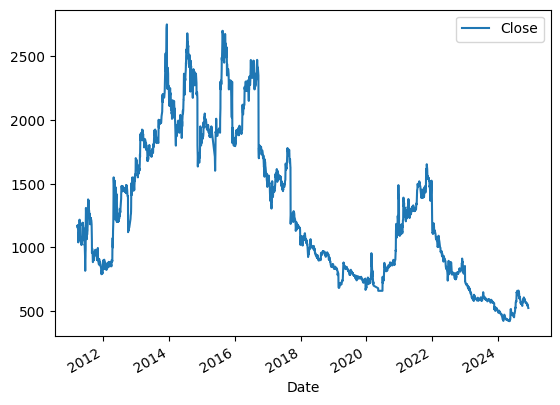

In [48]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
data = df[['Close']]
data.plot()


<Axes: xlabel='Date'>

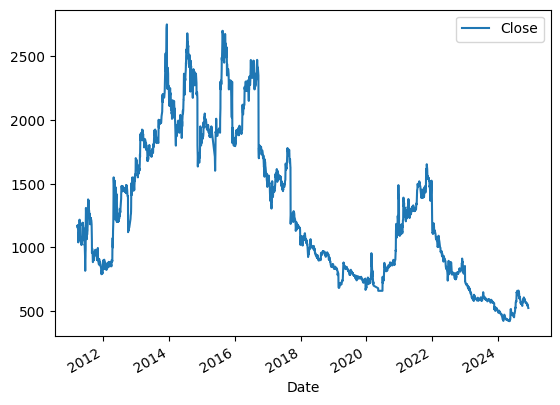

In [49]:
import numpy as np
# data = np.log(data) #don't forget to transform the data back when making real predictions
data.plot()

In [50]:
train_size = int(len(data) * 0.8)  # 80% of the data for training
data_train = data.iloc[:train_size].copy()  # First 80% for training
data_test = data.iloc[train_size:].copy()   # Last 20% for testing

In [51]:
# STEP 1: Check for stationary of time series
# Method #1: Time series plot (yadi simple data xa vane, we can simply check stationary through time series plot)
# Method #2: ACF plot and PACF plot (since stock market data is so complex, we should plot ACF, and PACF)

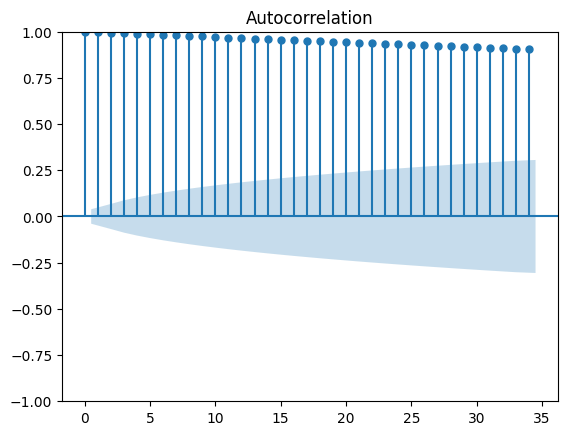

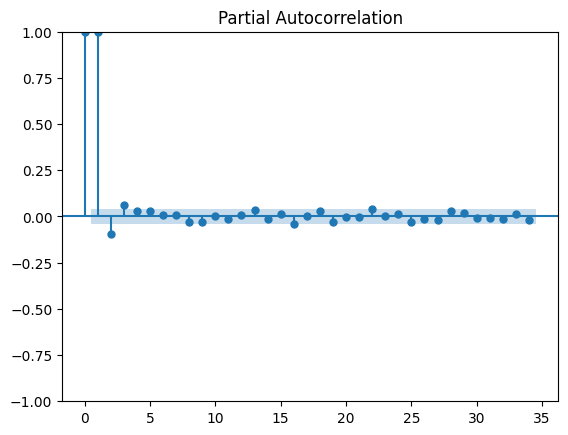

In [52]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
acf_original = plot_acf(data_train)
pacf_original = plot_pacf(data_train)

In [53]:
#Method #3: ADF test

In [54]:
from statsmodels.tsa.stattools import adfuller
adf_test = adfuller(data_train)
print(f'p-value: {adf_test[1]}')

p-value: 0.41762815694720307


In [55]:
#Transform to stationary: differencing

<Axes: xlabel='Date'>

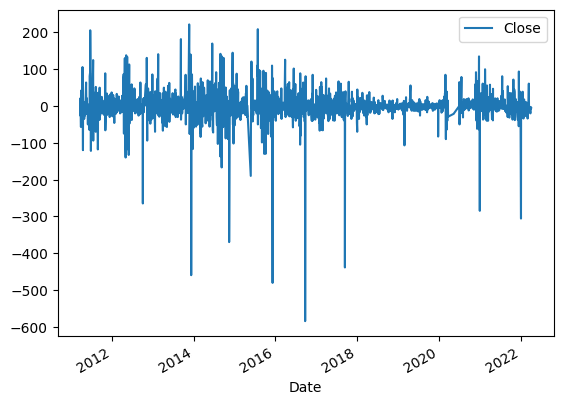

In [56]:
data_train_diff = data_train.diff().dropna()
data_train_diff.plot()


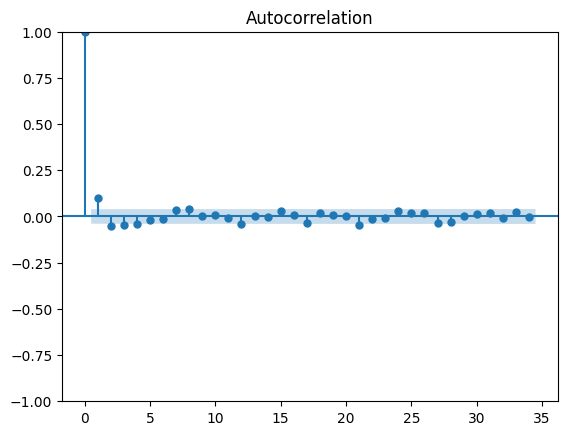

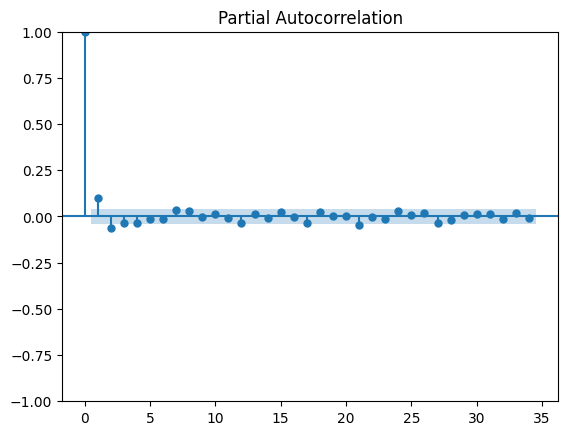

In [57]:
acf_diff = plot_acf(data_train_diff)
pacf_diff = plot_pacf(data_train_diff)

In [58]:
adf_test = adfuller(data_train_diff)
print(f'p-value: {adf_test[1]}')

p-value: 0.0


In [59]:
# ARIMA(p,1, q)
# STEP 2: Determine ARIMA models parameters p,q
# Fit the ARIMA model

In [60]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(data_train, order=(0,2,1))
model_fit = model.fit()
print(model_fit.summary())

c:\Users\BBhuwan\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\BBhuwan\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\BBhuwan\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2500
Model:                 ARIMA(0, 2, 1)   Log Likelihood              -12694.866
Date:                Mon, 24 Feb 2025   AIC                          25393.732
Time:                        21:12:53   BIC                          25405.379
Sample:                             0   HQIC                         25397.960
                               - 2500                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9992      0.004   -272.361      0.000      -1.006      -0.992
sigma2      1515.4258      8.501    178.255      0.000    1498.763    1532.088
Ljung-Box (L1) (Q):                  24.96   Jarque-

In [61]:
# STEP-4: Make time series predictions

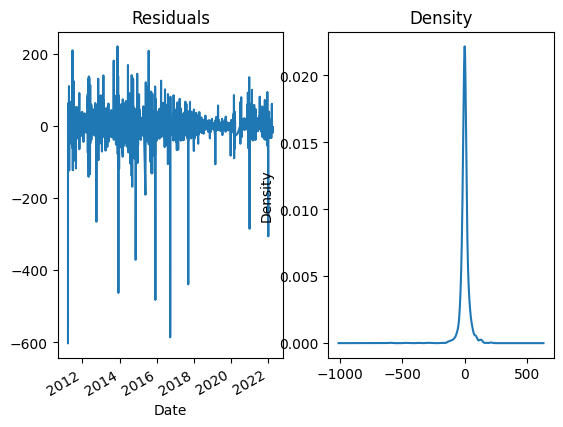

In [62]:
import matplotlib.pyplot as plt
residuals = model_fit.resid[1:]
fig, ax = plt.subplots(1,2)
residuals.plot(title = 'Residuals', ax = ax[0])
residuals.plot(title = 'Density', kind='kde', ax=ax[1])
plt.show()

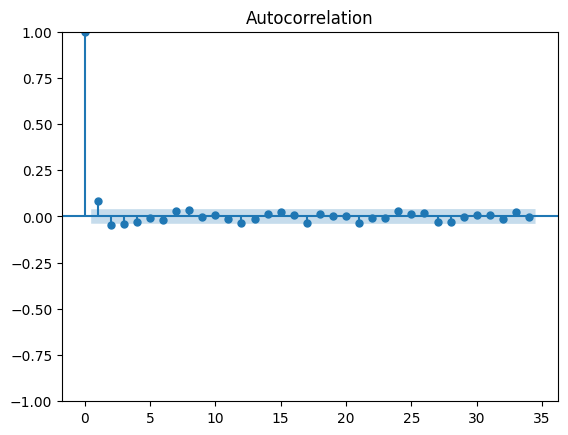

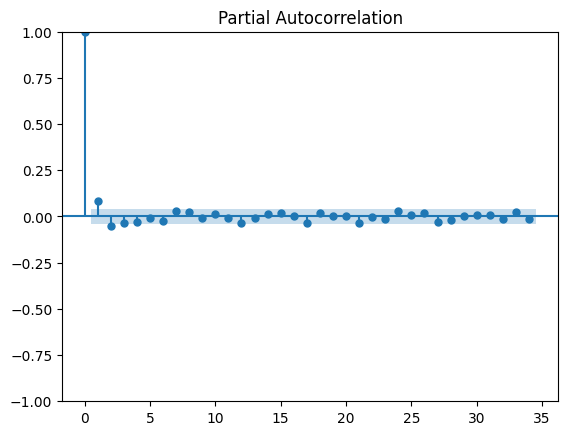

In [63]:
acf_res = plot_acf(residuals)
pacf_res = plot_pacf(residuals)


In [64]:
# forecast_test = model_fit.forecast(len(data_test))
# data['forecast_manual'] = [None]*len(data_train) + list(forecast_test)
# data.plot()
# # print(len(data_test))  # Should return a positive integer


In [65]:
# Forecast for 100 days
future_forecast = model_fit.forecast(30)

# Create a new DataFrame with future dates
future_dates = pd.date_range(start=data.index[-1], periods=31, freq='D')[1:]
forecast_df = pd.DataFrame({'Date': future_dates, 'Close': future_forecast})
forecast_df.set_index('Date', inplace=True)

# Display the forecasted prices
print(forecast_df.head())


                 Close
Date                  
2024-12-06  996.780001
2024-12-07  996.560002
2024-12-08  996.340004
2024-12-09  996.120005
2024-12-10  995.900006


c:\Users\BBhuwan\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\BBhuwan\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


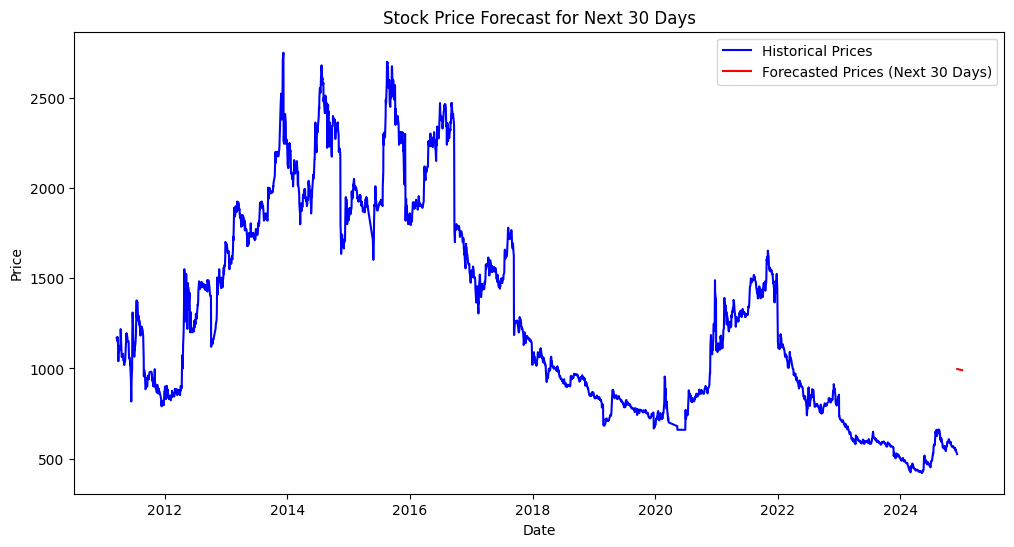

In [66]:
import matplotlib.pyplot as plt

# Merge forecast with original data
data_with_forecast = pd.concat([data, forecast_df])
# Plot historical & forecasted prices
plt.figure(figsize=(12,6))
plt.plot(data.index, data["Close"], label="Historical Prices", color="blue")
plt.plot(forecast_df.index, forecast_df["Close"], label="Forecasted Prices (Next 30 Days)", color="red")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Stock Price Forecast for Next 30 Days")
plt.show()
